# Data Visualizations

In [2]:
import os, re, glob
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
os.environ.setdefault("MLFLOW_TRACKING_URI", "file:///Users/dpham/mlruns_ml_pipeline")

from mlflow import MlflowClient
import polars as pl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sns.set_theme(context="paper", style="ticks", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "Arial",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

GREY = "#7a7a7a"
ACCENT = sns.color_palette("mako", n_colors=6)[2]

MODELS = {
    "Logistic Regression": ("logistic_regression_survey_weights", "data/test_labeled_logistic_regression_iter*.parquet"),
    "XGBoost": ("xgboost_survey_weights", "data/test_labeled_xgboost_iter*.parquet"),
    "Neural Network": ("neural_network_survey_weights", "data/test_labeled_neural_network_iter*.parquet"),
}
VARIANTS = ("standard", "survey_weighted")
TARGET = "Disability (recoded)_With a disability"
TRUE_POSITIVE_RATE = 0.1214

client = MlflowClient()

MODELS = {m: cfg for m, cfg in MODELS.items()
          if client.get_experiment_by_name(cfg[0]) is not None}
MODEL_ORDER = list(MODELS.keys())

# Pulls each test iterations and averages out test set metrics
TEST_RE = re.compile(r"^(standard|survey_weighted)_iter(\d+)_test$")
latest = {}
for model, (exp_name, _) in MODELS.items():
    exp = client.get_experiment_by_name(exp_name)
    for run in client.search_runs([exp.experiment_id], max_results=5000):
        m = TEST_RE.match(run.data.tags.get("mlflow.runName", ""))
        if not m:
            continue
        key = (model, m.group(1), int(m.group(2)))
        if key not in latest or run.info.start_time > latest[key][0]:
            latest[key] = (run.info.start_time, run.data.metrics)

rows = []
for (model, variant, _it), (_start, metrics) in latest.items():
    for k, v in metrics.items():
        if not k.startswith("test_"):
            continue
        _, weighting, metric = k.split("_", 2)
        rows.append({"model": model, "variant": variant,
                     "weighting": weighting, "metric": metric, "value": v})

metrics_df = (pd.DataFrame(rows)
                .groupby(["model", "variant", "weighting", "metric"], as_index=False)["value"]
                .mean())

n_iter = {m: len({it for (mm, _v, it) in latest if mm == m}) for m in MODEL_ORDER}
counts = sorted(set(n_iter.values()))
N_ITER = str(counts[0]) if len(counts) == 1 else f"{counts[0]}-{counts[-1]}"

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Figure 1

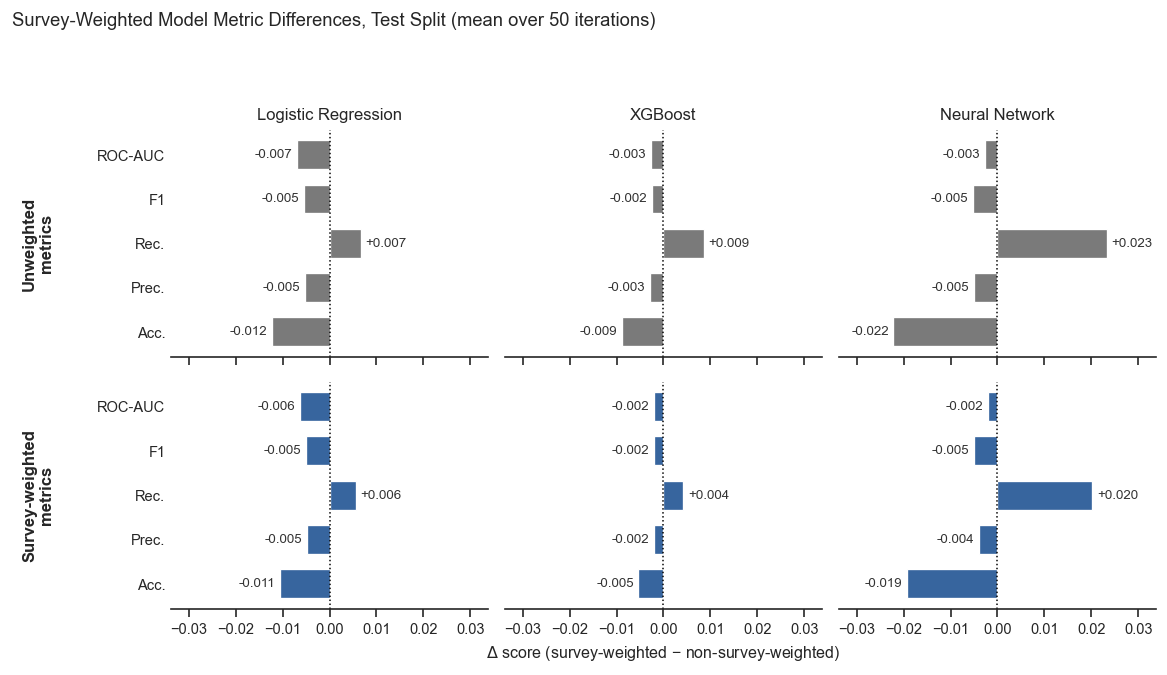

In [3]:
metric_order = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = {"accuracy": "Acc.", "precision": "Prec.", "recall": "Rec.",
                 "f1": "F1", "roc_auc": "ROC-AUC"}

delta_df = (metrics_df.pivot_table(index=["model", "weighting", "metric"],
                                   columns="variant", values="value")
                      .reset_index())
delta_df["delta"] = delta_df["survey_weighted"] - delta_df["standard"]

row_weightings = [("unweighted", "Unweighted\nmetrics"),
                  ("weighted", "Survey-weighted\nmetrics")]

ncols = len(MODEL_ORDER)
fig, axes = plt.subplots(2, ncols, figsize=(3.2 * ncols + 0.3, 5.6),
                         sharex=True, sharey=True, squeeze=False)
xmax = float(delta_df["delta"].abs().max()) * 1.45
for r, (weighting, rlabel) in enumerate(row_weightings):
    sub = delta_df[delta_df["weighting"] == weighting]
    for c, model in enumerate(MODEL_ORDER):
        ax = axes[r, c]
        row = sub[sub["model"] == model].set_index("metric").loc[metric_order]
        colors = [GREY if r == 0 else ACCENT] * len(row["delta"])
        y_labels = [metric_labels[m] for m in metric_order]
        ax.barh(y_labels, row["delta"].values, color=colors, height=0.65)
        for y, d in enumerate(row["delta"].values):
            ax.text(d + (0.001 if d >= 0 else -0.001), y, f"{d:+.3f}",
                    ha="left" if d >= 0 else "right", va="center", fontsize=8,
                    color="#333333")
        ax.axvline(0, color="black", linewidth=0.9, linestyle=":")
        ax.set_xlim(-xmax, xmax)
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", length=0)
        ax.invert_yaxis()
        if r == 0:
            ax.set_title(model, fontsize=10)
    axes[r, 0].annotate(rlabel, xy=(-0.42, 0.5), xycoords="axes fraction",
                        rotation=90, ha="center", va="center",
                        fontsize=10, fontweight="bold")
axes[1, ncols // 2].set_xlabel(r"$\Delta$ score (survey-weighted − non-survey-weighted)")
fig.suptitle(f"Survey-Weighted Model Metric Differences, Test Split (mean over {N_ITER} iterations)",
             x=0.02, y=0.995, ha="left", fontsize=11)
fig.tight_layout(rect=[0.03, 0, 1, 0.93])
plt.show()

## Figure 2

KeyboardInterrupt: 

Exception ignored in: 'zmq.backend.cython._zmq.Frame.__del__'
Traceback (most recent call last):
  File "_zmq.py", line 160, in zmq.backend.cython._zmq._check_rc
KeyboardInterrupt: 


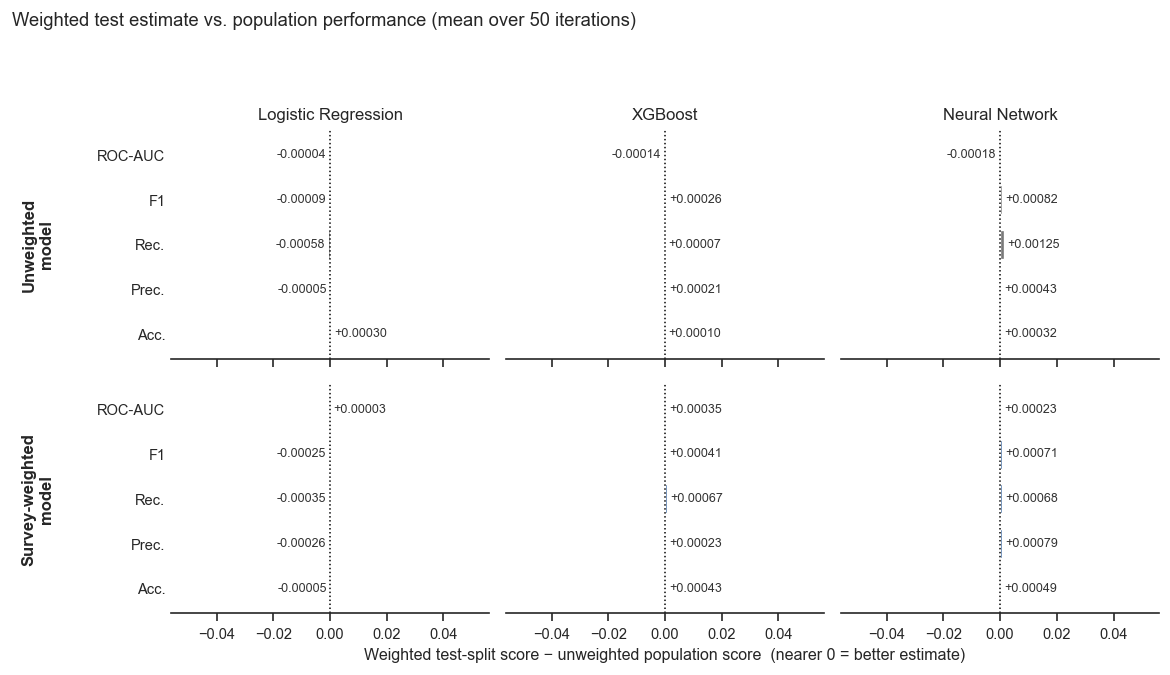

In [4]:
from matplotlib.patches import Patch

POP_RE = re.compile(r"^(standard|survey_weighted)_iter(\d+)_population$")
pop_rows = []
for model, (exp_name, _) in MODELS.items():
    exp = client.get_experiment_by_name(exp_name)
    for run in client.search_runs([exp.experiment_id], max_results=5000):
        if not POP_RE.match(run.data.tags.get("mlflow.runName", "")):
            continue
        variant = run.data.tags["mlflow.runName"].split("_iter")[0]
        for k, v in run.data.metrics.items():
            pop_rows.append({"model": model, "variant": variant,
                             "metric": k.replace("population_unweighted_", ""),
                             "population": v})
pop_df = (pd.DataFrame(pop_rows)
            .groupby(["model", "variant", "metric"], as_index=False)["population"].mean())

test_df = (metrics_df[metrics_df["weighting"] == "weighted"]
           .rename(columns={"value": "test"})[["model", "variant", "metric", "test"]])
gen_df = pop_df.merge(test_df, on=["model", "variant", "metric"])
gen_df["gap"] = gen_df["test"] - gen_df["population"]

# Shared x-axis for Figures 2 and 3: both are scaled to the UNWEIGHTED gaps
# (the larger of the two) so the bars mean the same amount of difference in
# both figures. On this common scale the weighted gaps here read as ~0.
test_u = (metrics_df[metrics_df["weighting"] == "unweighted"]
          .rename(columns={"value": "test"})[["model", "variant", "metric", "test"]])
gen_u = pop_df.merge(test_u, on=["model", "variant", "metric"])
gen_u["gap"] = gen_u["test"] - gen_u["population"]
SHARED_XMAX = float(gen_u["gap"].abs().max()) * 1.8

row_variants = [("standard", "Unweighted\nmodel", GREY),
                ("survey_weighted", "Survey-weighted\nmodel", ACCENT)]

ncols = len(MODEL_ORDER)
fig, axes = plt.subplots(2, ncols, figsize=(3.2 * ncols + 0.3, 5.6),
                         sharex=True, sharey=True, squeeze=False)
xmax = SHARED_XMAX
off = xmax * 0.02
for r, (variant, rlabel, color) in enumerate(row_variants):
    sub_v = gen_df[gen_df["variant"] == variant]
    for c, model in enumerate(MODEL_ORDER):
        ax = axes[r, c]
        row = sub_v[sub_v["model"] == model].set_index("metric").loc[metric_order]
        y_labels = [metric_labels[m] for m in metric_order]
        ax.barh(y_labels, row["gap"].values, color=color, height=0.65)
        for y, g in enumerate(row["gap"].values):
            ax.text(g + (off if g >= 0 else -off), y, f"{g:+.5f}",
                    ha="left" if g >= 0 else "right", va="center",
                    fontsize=7.5, color="#333333")
        ax.axvline(0, color="black", linewidth=0.9, linestyle=":")
        ax.set_xlim(-xmax, xmax)
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", length=0)
        ax.invert_yaxis()
        if r == 0:
            ax.set_title(model, fontsize=10)
    axes[r, 0].annotate(rlabel, xy=(-0.42, 0.5), xycoords="axes fraction",
                        rotation=90, ha="center", va="center",
                        fontsize=10, fontweight="bold")
axes[1, ncols // 2].set_xlabel(
    "Weighted test-split score − unweighted population score  (nearer 0 = better estimate)")
fig.suptitle(f"Weighted test estimate vs. population performance (mean over {N_ITER} iterations)",
             x=0.02, y=0.995, ha="left", fontsize=11)
fig.tight_layout(rect=[0.03, 0, 1, 0.93])
plt.show()


## Figure 3

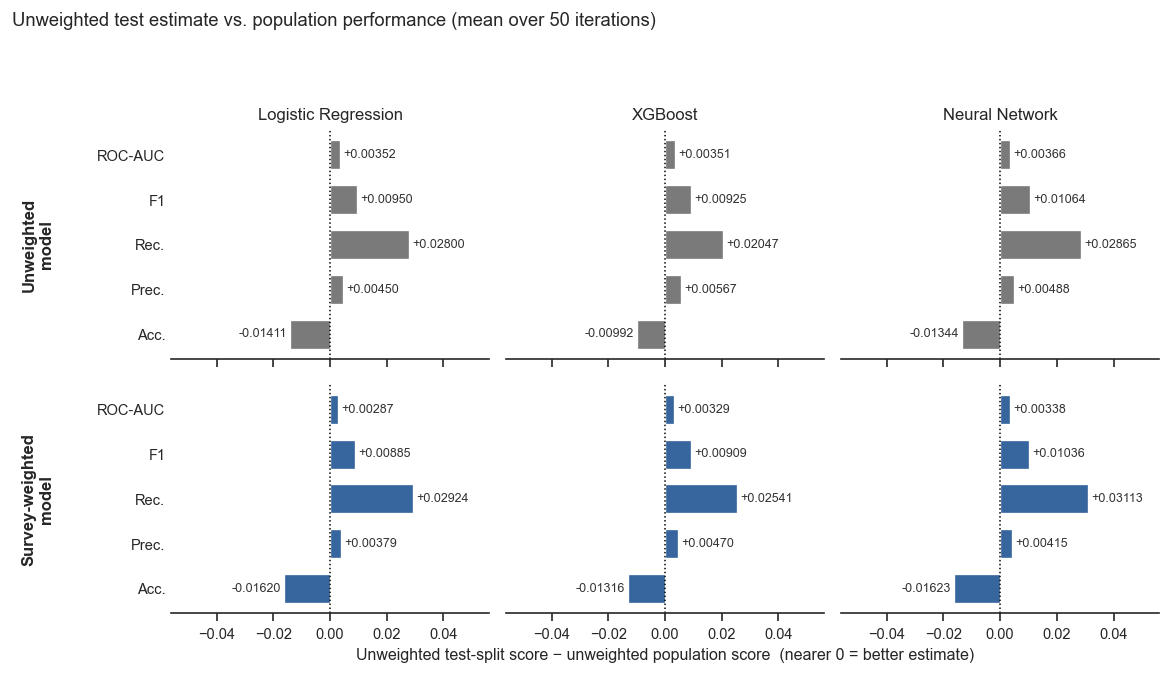

In [ ]:
from matplotlib.patches import Patch

# Twin of Figure 2, but the test-split score is UNWEIGHTED:
# gap = unweighted test-split score − unweighted population score. Same 2x3
# format (rows = model fitting variant, columns = models, one bar per metric)
# so it reads directly against Figure 2's weighted version. It shares Figure 2's
# x-axis (SHARED_XMAX) so a bar of a given length means the same difference in
# both figures — the unweighted gaps here fill the axis while Figure 2's
# weighted gaps sit near 0.
POP_RE = re.compile(r"^(standard|survey_weighted)_iter(\d+)_population$")
pop_rows = []
for model, (exp_name, _) in MODELS.items():
    exp = client.get_experiment_by_name(exp_name)
    for run in client.search_runs([exp.experiment_id], max_results=5000):
        if not POP_RE.match(run.data.tags.get("mlflow.runName", "")):
            continue
        variant = run.data.tags["mlflow.runName"].split("_iter")[0]
        for k, v in run.data.metrics.items():
            pop_rows.append({"model": model, "variant": variant,
                             "metric": k.replace("population_unweighted_", ""),
                             "population": v})
pop_df = (pd.DataFrame(pop_rows)
            .groupby(["model", "variant", "metric"], as_index=False)["population"].mean())

test_df = (metrics_df[metrics_df["weighting"] == "unweighted"]
           .rename(columns={"value": "test"})[["model", "variant", "metric", "test"]])
gen_u_df = pop_df.merge(test_df, on=["model", "variant", "metric"])
gen_u_df["gap"] = gen_u_df["test"] - gen_u_df["population"]

row_variants = [("standard", "Unweighted\nmodel", GREY),
                ("survey_weighted", "Survey-weighted\nmodel", ACCENT)]

ncols = len(MODEL_ORDER)
fig, axes = plt.subplots(2, ncols, figsize=(3.2 * ncols + 0.3, 5.6),
                         sharex=True, sharey=True, squeeze=False)
xmax = SHARED_XMAX
off = xmax * 0.02
for r, (variant, rlabel, color) in enumerate(row_variants):
    sub_v = gen_u_df[gen_u_df["variant"] == variant]
    for c, model in enumerate(MODEL_ORDER):
        ax = axes[r, c]
        row = sub_v[sub_v["model"] == model].set_index("metric").loc[metric_order]
        y_labels = [metric_labels[m] for m in metric_order]
        ax.barh(y_labels, row["gap"].values, color=color, height=0.65)
        for y, g in enumerate(row["gap"].values):
            ax.text(g + (off if g >= 0 else -off), y, f"{g:+.5f}",
                    ha="left" if g >= 0 else "right", va="center",
                    fontsize=7.5, color="#333333")
        ax.axvline(0, color="black", linewidth=0.9, linestyle=":")
        ax.set_xlim(-xmax, xmax)
        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", length=0)
        ax.invert_yaxis()
        if r == 0:
            ax.set_title(model, fontsize=10)
    axes[r, 0].annotate(rlabel, xy=(-0.42, 0.5), xycoords="axes fraction",
                        rotation=90, ha="center", va="center",
                        fontsize=10, fontweight="bold")
axes[1, ncols // 2].set_xlabel(
    "Unweighted test-split score − unweighted population score  (nearer 0 = better estimate)")
fig.suptitle(f"Unweighted test estimate vs. population performance (mean over {N_ITER} iterations)",
             x=0.02, y=0.995, ha="left", fontsize=11)
fig.tight_layout(rect=[0.03, 0, 1, 0.93])
plt.show()


## Figure 4

In [ ]:
# labeled = {}
# for name, (_, pattern) in MODELS.items():
#     labeled[name] = pl.concat([pl.read_parquet(f) for f in sorted(glob.glob(pattern))])
#
# rate_rows = []
# for model, df in labeled.items():
#     for variant in VARIANTS:
#         pred = df[f"predicted_disability_{variant}"].to_numpy()
#         rate_rows.append({"model": model, "variant": variant, "rate": float(pred.mean())})
# rate_df = pd.DataFrame(rate_rows)

In [ ]:
# from matplotlib.patches import Patch
# from matplotlib.lines import Line2D
#
# fig, ax = plt.subplots(figsize=(6.6, 3.8))
# y = np.arange(len(MODEL_ORDER))
# for j, variant in enumerate(VARIANTS):
#     rates = [rate_df[(rate_df["model"] == m) & (rate_df["variant"] == variant)]["rate"].iloc[0]
#              for m in MODEL_ORDER]
#     color = GREY if variant == "standard" else ACCENT
#     offset = -0.2 if j == 0 else 0.2
#     ax.barh(y + offset, rates, height=0.35, color=color)
#     for i, r in enumerate(rates):
#         ax.text(r + 0.006, i + offset, f"{r:.3f}", va="center",
#                 fontsize=7.5, color="#333333")
# ax.axvline(TRUE_POSITIVE_RATE, color="black", linestyle=":", linewidth=1.2)
# ax.set_yticks(y)
# ax.set_yticklabels(MODEL_ORDER, fontsize=9)
# ax.set_xlim(0, 0.58)
# ax.set_xlabel("Predicted positive rate")
# ax.spines["left"].set_visible(False)
# ax.tick_params(axis="y", length=0)
# ax.invert_yaxis()
#
# handles = [
#     Patch(color=GREY,   label="Standard fitting"),
#     Patch(color=ACCENT, label="Survey-weighted fitting"),
#     Line2D([0], [0], color="black", linestyle=":", linewidth=1.2,
#            label=f"Actual disability rate in test data ({TRUE_POSITIVE_RATE:.1%})"),
# ]
# fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.02),
#            ncol=3, frameon=False, fontsize=9)
#
# fig.suptitle(f"Predicted vs Actual Disability Rate (mean over {N_ITER} iterations)",
#              x=0.02, y=0.995, ha="left", fontsize=11)
# fig.tight_layout(rect=[0, 0.08, 1, 0.93])
# plt.show()

## Figure 5

In [ ]:
# nrows = len(MODEL_ORDER)
# fig, axes = plt.subplots(nrows, 2, figsize=(6.6, 2.7 * nrows + 0.5), squeeze=False)
# for i, (model, df) in enumerate(labeled.items()):
#     y = df[TARGET].to_numpy()
#     for j, variant in enumerate(VARIANTS):
#         pred = df[f"predicted_disability_{variant}"].to_numpy()
#         cm = confusion_matrix(y, pred, normalize="all") * 100
#         annot = np.array([[f"{v:.1f}%" for v in row] for row in cm])
#         sns.heatmap(cm, annot=annot, fmt="", cmap="mako", ax=axes[i, j],
#                     cbar=False, vmin=0, vmax=100,
#                     xticklabels=["False", "True"], yticklabels=["False", "True"],
#                     annot_kws={"color": "white", "fontsize": 9.5},
#                     linewidths=0.3, linecolor="white")
#         if i == 0:
#             axes[i, j].set_title(variant.replace("_", "-"), fontsize=10)
#         axes[i, j].set_xlabel("Predicted" if i == nrows - 1 else "", fontsize=9)
#         if j == 0:
#             axes[i, j].set_ylabel("Actual", fontsize=9)
#             axes[i, j].annotate(model, xy=(-0.32, 0.5), xycoords="axes fraction",
#                                 ha="center", va="center", rotation=90,
#                                 fontsize=10, fontweight="bold")
#         else:
#             axes[i, j].set_ylabel("")
#         axes[i, j].tick_params(length=0)
#
# fig.suptitle(f"Confusion matrices (pooled over {N_ITER} iterations)",
#              x=0.02, y=0.995, ha="left", fontsize=11)
# fig.tight_layout(rect=[0.04, 0, 1, 0.965])
# plt.show()

## Figure 6

In [ ]:
# from matplotlib.lines import Line2D
# from matplotlib.patches import Patch
#
# bins = np.linspace(0, 1, 41)
# ncols = len(MODEL_ORDER)
# fig, axes = plt.subplots(1, ncols, figsize=(3.2 * ncols + 0.3, 3.2),
#                          sharey=True, squeeze=False)
# for c, model in enumerate(MODEL_ORDER):
#     ax = axes[0, c]
#     df = labeled[model]
#     y = df[TARGET].to_numpy()
#     for variant in VARIANTS:
#         p = df[f"predicted_proba_{variant}"].to_numpy()
#         color = GREY if variant == "standard" else ACCENT
#         ax.hist(p[y == 1], bins=bins, density=True, histtype="step",
#                 linewidth=1.4, linestyle="-", color=color)
#         ax.hist(p[y == 0], bins=bins, density=True, histtype="step",
#                 linewidth=1.1, linestyle="--", color=color)
#     ax.axvline(TRUE_POSITIVE_RATE, color="black", linestyle=":", linewidth=1)
#     ax.set_title(model, fontsize=10)
#     ax.set_xlabel("Predicted probability", fontsize=9)
#     ax.set_xlim(0, 1)
#     if c == 0:
#         ax.set_ylabel("Density", fontsize=9)
#
# handles = [Patch(color=GREY, label="Standard fitting"),
#            Patch(color=ACCENT, label="Survey-weighted fitting"),
#            Line2D([0], [0], color="#333333", linestyle="-", label="Actual positives"),
#            Line2D([0], [0], color="#333333", linestyle="--", label="Actual negatives")]
# fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.04),
#            ncol=4, frameon=False, fontsize=9)
# fig.suptitle(f"Predicted-probability distributions by true class (pooled over {N_ITER} iterations)",
#              x=0.02, y=0.99, ha="left", fontsize=11)
# fig.tight_layout(rect=[0, 0.06, 1, 0.93])
# plt.show()